密度估计

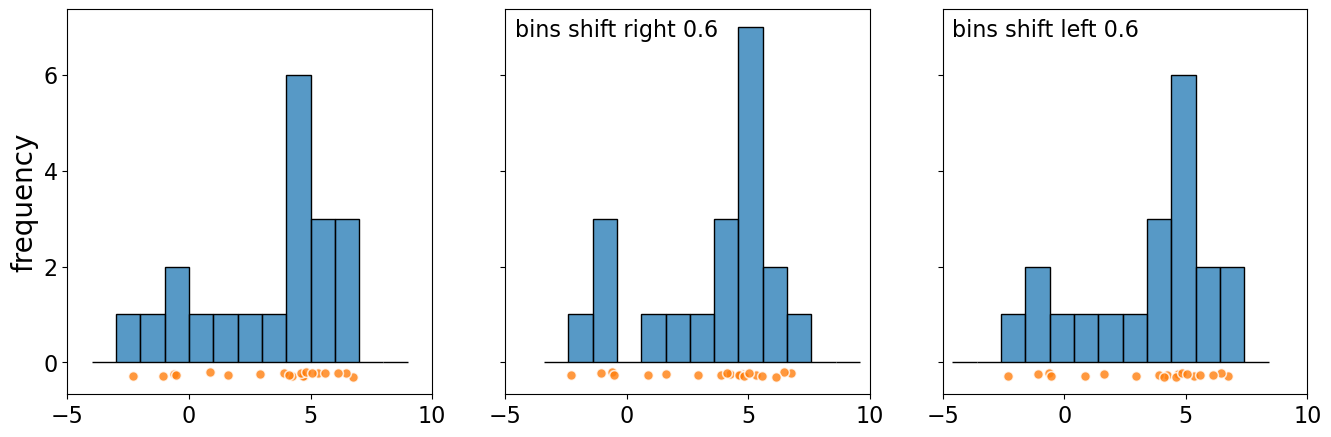

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st


np.random.seed(1)
N, shift = 20, 0.6
X = np.concatenate((st.norm.rvs(0, 1, size=int(0.3 * N)), st.norm.rvs(5, 1, size=int(0.7 * N))))
bins = np.linspace(-4, 9, 14)

plt.rcParams.update({
    "axes.unicode_minus": True,
    "font.size": 16,
    'axes.labelsize': '20',
})

fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
x, y = -4.6, 6.8
sns.histplot(X, bins=bins, stat="frequency", ax=axs[0])
axs[0].set_ylabel("frequency")
sns.histplot(X, bins=bins + shift, stat="frequency", ax=axs[1])
axs[1].text(x, y, f"bins shift right {shift}")
sns.histplot(X, bins=bins - shift, stat="frequency", ax=axs[2])
axs[2].text(x, y, f"bins shift left {shift}")

for ax in axs:
    sns.scatterplot(x=X, y=-0.2 - 0.1 * st.uniform.rvs(size=len(X)), s=200, alpha=0.8, marker='.', ax=ax)
    ax.set_xlim(-5, 10)

plt.show()

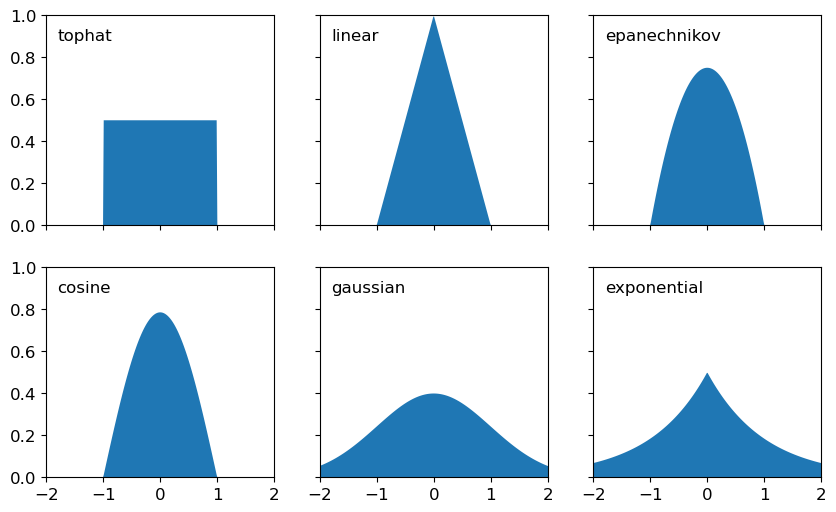

In [3]:
from sklearn.neighbors import KernelDensity

X_plot = np.linspace(-6, 6, 1000)

plt.rcParams.update({
    "axes.unicode_minus": True,
    "font.size": 12,
})

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 6))
for ax, kernel in zip(axs.ravel(), ['tophat', 'linear', 'epanechnikov', 'cosine', 'gaussian', 'exponential']):
    log_dens = KernelDensity(kernel=kernel).fit([[0]]).score_samples(X_plot.reshape(-1, 1))
    ax.fill(X_plot, np.exp(log_dens))
    ax.text(-1.8, 0.88, kernel)
    ax.set(xlim=(-2, 2), ylim=(0, 1))

plt.show()

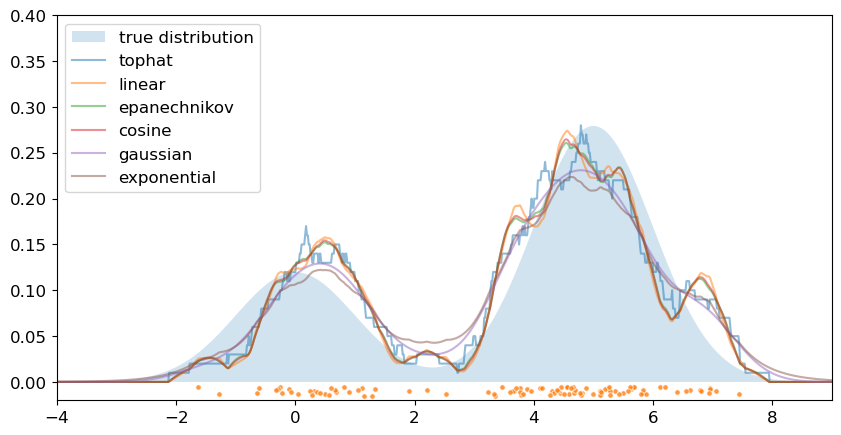

In [5]:
N = 100
X = np.concatenate((st.norm.rvs(0, 1, size=int(0.3 * N)), st.norm.rvs(5, 1, size=int(0.7 * N))))
X_plot = np.linspace(-5, 10, 1000)
true_dens = (0.3 * st.norm(0, 1).pdf(X_plot) + 0.7 * st.norm(5, 1).pdf(X_plot))

plt.rcParams.update({
    "axes.unicode_minus": True,
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill(X_plot, true_dens, alpha=0.2, label='true distribution')

for kernel in ['tophat', 'linear', 'epanechnikov', 'cosine', 'gaussian', 'exponential']:
    log_dens = KernelDensity(kernel=kernel, bandwidth=0.5).fit(X.reshape(-1, 1)).score_samples(X_plot.reshape(-1, 1))
    sns.lineplot(x=X_plot, y=np.exp(log_dens), alpha=0.5, label=f"{kernel}", ax=ax)

sns.scatterplot(x=X, y=-0.005 - 0.01 * st.uniform.rvs(size=len(X)), s=60, alpha=0.8, marker='.', ax=ax)
ax.set(xlim=(-4, 9), ylim=(-0.02, 0.4))

plt.show()